Dataset loaded successfully. Initial shape: (120, 5)
Rohith John 24BAD100
Unique values in Income column before cleaning: [0 1]
Shape after encoding features: (120, 5)
Successfully split data! Training samples: 96, Testing samples: 24

Training Random Forest models with varying number of trees...
Trees:  10 | Accuracy: 100.00%
Trees:  50 | Accuracy: 100.00%
Trees: 100 | Accuracy: 100.00%
Trees: 150 | Accuracy: 100.00%
Trees: 200 | Accuracy: 100.00%
Trees: 250 | Accuracy: 100.00%


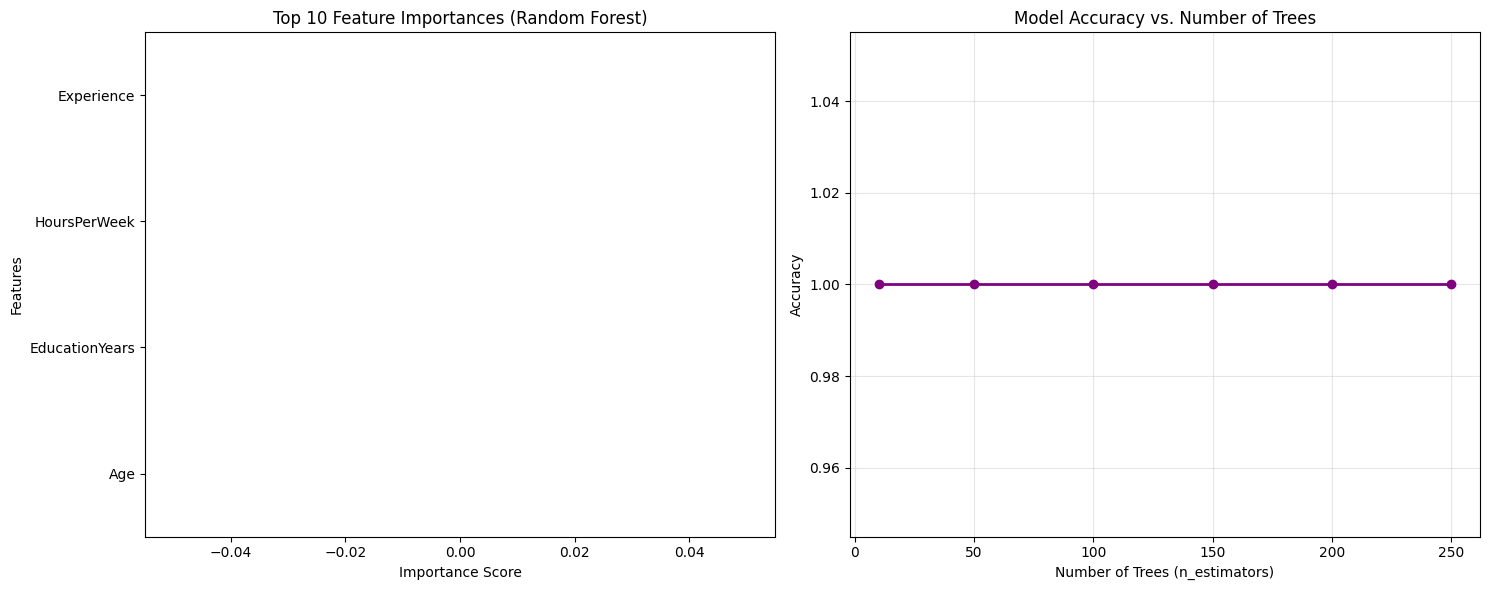

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load the dataset
# IMPORTANT FOR COLAB: Ensure you have clicked the folder icon on the left
# and uploaded 'income_random_forest.csv' to the session storage.
try:
    df = pd.read_csv('income_random_forest.csv')
    print(f"Dataset loaded successfully. Initial shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'income_random_forest.csv' not found. Please upload it to Colab.")
    raise
print("Rohith John 24BAD100")
# --- Robust Data Preprocessing ---
# Strip any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

if 'Income' in df.columns:
    # Print unique values so you can see exactly what text is in your file
    print(f"Unique values in Income column before cleaning: {df['Income'].unique()}")

    # Flexible mapping: If the string contains '>50', assign 1. Otherwise, 0.
    df['Income'] = df['Income'].astype(str).apply(lambda x: 1 if '>50' in x else 0)
else:
    print("\nWARNING: 'Income' column not found! Here are the columns your file actually has:")
    print(df.columns.tolist())
    print("Please rename the target column in your CSV to 'Income' or update the code above.")
    raise KeyError("Target column 'Income' missing.")

# One-hot encode categorical features
df = pd.get_dummies(df, drop_first=True)
print(f"Shape after encoding features: {df.shape}")

# Separate features (X) and target variable (y)
X = df.drop('Income', axis=1)
y = df['Income']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Successfully split data! Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}\n")

# 2. Tune number of trees & Train Random Forest
n_estimators_list = [10, 50, 100, 150, 200, 250]
accuracies = []

print("Training Random Forest models with varying number of trees...")
for n_trees in n_estimators_list:
    rf_model = RandomForestClassifier(n_estimators=n_trees, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    predictions = rf_model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)
    print(f"Trees: {n_trees:3d} | Accuracy: {acc * 100:.2f}%")

# 3. Evaluate model (using a standard 100 trees for feature importance)
final_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

# ----------------- Visualizations -----------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualization 1: Feature Importance (Top 10 features)
feature_importances = pd.Series(final_model.feature_importances_, index=X.columns)
top_features = feature_importances.nlargest(10)

top_features.sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 10 Feature Importances (Random Forest)')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Features')

# Visualization 2: Accuracy vs Number of Trees Graph
axes[1].plot(n_estimators_list, accuracies, marker='o', linestyle='-', color='purple', linewidth=2)
axes[1].set_title('Model Accuracy vs. Number of Trees')
axes[1].set_xlabel('Number of Trees (n_estimators)')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()